In [1]:
# IMPORTS
import torch
import torch.nn as nn
from binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supress warnings
import warnings
warnings.filterwarnings("ignore")

--- DEBUG INFO ---
Current File: /data/users/thomath/kand/BINN/data_handling.py
Current Working Directory: /data/users/thomath/kand/BINN
Python Path:
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
  
  /data/users/thomath/.venv/lib/python3.12/site-packages
------------------


/data/users/thomath/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 32
EPOCHS = 400
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

# PARAMETERS
LR = 5e-4
WEIGHT_DECAY = 0.3
DROPOUT = 1.699e-1
ACTIVATION_FN = nn.Tanh()

# OPTUNA TUNED HYPERPARAMETERS: LR = 9.76e-3, WEIGHT_DECAY = 9.96e-2, DROPOUT = 1.699e-1

# OTHER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PATHS
base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"

In [3]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [4]:
datasets["astro"]

AnnData object with n_obs × n_vars = 1235 × 1000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'mean'

In [5]:
datasets["astro"].obs


,subject,cell_type_high_resolution,n_obs_aggregated,AD_status
ROSMAP-10132_Ast CHI3L1,ROSMAP-10132,Ast CHI3L1,14,1.0
ROSMAP-10132_Ast DPP10,ROSMAP-10132,Ast DPP10,138,1.0
ROSMAP-10132_Ast GRM3,ROSMAP-10132,Ast GRM3,508,1.0
ROSMAP-10643_Ast CHI3L1,ROSMAP-10643,Ast CHI3L1,29,1.0
ROSMAP-10643_Ast DPP10,ROSMAP-10643,Ast DPP10,57,1.0
...,...,...,...,...
ROSMAP-99585_Ast DPP10,ROSMAP-99585,Ast DPP10,99,1.0
ROSMAP-99585_Ast GRM3,ROSMAP-99585,Ast GRM3,12,1.0
ROSMAP-99981_Ast CHI3L1,ROSMAP-99981,Ast CHI3L1,8,1.0
ROSMAP-99981_Ast DPP10,ROSMAP-99981,Ast DPP10,31,1.0


In [6]:
# FROM GEMINI - Pseudobulk per patient only
patient_datasets = dh.rollup_to_patient_level(datasets)

Rolling up 'astro'...
Rolling up 'exc1'...
Rolling up 'exc2'...
Rolling up 'exc3'...
Rolling up 'immune'...
Rolling up 'inhi'...
Rolling up 'oligo'...
Rolling up 'opcs'...
Rolling up 'vasc'...


In [7]:
patient_datasets["astro"].obs

,subject,n_obs_mean,cell_type_high_resolution,AD_status
subject,,,,
ROSMAP-10132,ROSMAP-10132,220.000000,astro,1.0
ROSMAP-10643,ROSMAP-10643,165.000000,astro,1.0
ROSMAP-10859,ROSMAP-10859,101.000000,astro,1.0
ROSMAP-12078,ROSMAP-12078,74.333333,astro,1.0
ROSMAP-12256,ROSMAP-12256,139.666667,astro,1.0
...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,133.000000,astro,0.0
ROSMAP-98683,ROSMAP-98683,64.000000,astro,1.0
ROSMAP-99419,ROSMAP-99419,310.666667,astro,0.0


In [8]:
print("Reading masks...")
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Reading masks...
Matrix 0 shape: (976, 764)
Matrix 1 shape: (764, 417)
Matrix 2 shape: (417, 163)
Matrix 3 shape: (163, 29)
Matrix 4 shape: (29, 1)


In [9]:
print("Aligning adatas to BINN...")
datasets_aligned = dh.subset_genes(patient_datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 976 for astro
Overlapping genes kept: 976 for exc1
Overlapping genes kept: 976 for exc2
Overlapping genes kept: 976 for exc3
Overlapping genes kept: 976 for immune
Overlapping genes kept: 976 for inhi
Overlapping genes kept: 976 for oligo
Overlapping genes kept: 976 for opcs
Overlapping genes kept: 976 for vasc


In [10]:
datasets_aligned["astro"]

AnnData object with n_obs × n_vars = 427 × 976
    obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'

In [11]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligned, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'exc1': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'exc2': AnnData object with n_obs × n_vars = 425 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'exc3': AnnData object with n_obs × n_vars = 426 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'immune': AnnData object with n_obs × n_vars = 426 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'inhi': AnnData object with n_obs × n_vars = 423 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'oligo': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status',
 'opcs': AnnData object with n_obs × n_vars = 427 × 976
     obs:

In [12]:
# 
adata_global = dh.create_global_with_missing_patients(datasets_padded)

  Total unique subjects found: 427
  + Added astro (427 subjects)
  + Added exc1 (427 subjects)
  + Added exc2 (425 subjects)
  + Added exc3 (426 subjects)
  + Added immune (426 subjects)
  + Added inhi (423 subjects)
  + Added oligo (427 subjects)
  + Added opcs (427 subjects)
  + Added vasc (423 subjects)
Running Scanpy normalization...
Done! Final Global shape: (427, 976)


In [13]:
# Label sanity check 
adata_global.obs["AD_status"].value_counts()

AD_status
1.0    238
0.0    189
Name: count, dtype: int64

In [14]:
print("Creating global train/test split...")
train_adata_global, test_adata_global = ctts.custom_train_test_split(adata_global, train_size=TRAIN_SIZE)

Creating global train/test split...
Train Subjects: 341
Test Subjects: 86


In [15]:
print("Scaling genes to prevent leakage...")
train_adata_global, test_adata_global = dh.scaling_no_leakage(train_adata_global, test_adata_global)

Scaling genes to prevent leakage...


In [16]:
print("Getting dataloaders...")
#train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)
train_loader_global, test_loader_global = dh.create_dataloaders(train_adata_global, test_adata_global, batch_size=BATCH_SIZE)

Getting dataloaders...


In [17]:
#dh.inf_check(adata_global)

In [18]:
mask_matrix_list, in_features, layers_list, tensor_masks = dh.compute_features(masks, device)

input features: 976
layer list: [764, 417, 163, 29, 1]


In [19]:
# check for NaN-values etc.
dh.poison_scanner(train_loader_global, device)
dh.poison_scanner(test_loader_global, device)

No poison found!
No poison found!


In [20]:
# model is MLP with same layers as BINN 
binn, criterion, optimizer, scheduler = dh.create_model(in_features, layers_list, tensor_masks, device, 
                                                        lr=LR, weight_decay=WEIGHT_DECAY, dropout=DROPOUT, activation_fn=ACTIVATION_FN)
# Best hyperparams from Optuna {'lr': 0.009763668935486306, 'weight_decay': 0.09966656513852097, 'dropout': 0.16985580651321033}
binn

BINN(
  (activation_fn): Tanh()
  (dropout): Dropout(p=0.1699, inplace=False)
  (model_layers): ModuleList(
    (0): Linear(in_features=976, out_features=764, bias=True)
    (1): Linear(in_features=764, out_features=417, bias=True)
    (2): Linear(in_features=417, out_features=163, bias=True)
    (3): Linear(in_features=163, out_features=29, bias=True)
    (4): Linear(in_features=29, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((764,), eps=1e-05, elementwise_affine=True)
    (1): LayerNorm((417,), eps=1e-05, elementwise_affine=True)
    (2): LayerNorm((163,), eps=1e-05, elementwise_affine=True)
    (3): LayerNorm((29,), eps=1e-05, elementwise_affine=True)
  )
)

In [21]:
print(f"criterion: {criterion},\n optimizer: {optimizer}")

criterion: BCEWithLogitsLoss(),
 optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0005
    lr: 0.0005
    maximize: False
    weight_decay: 0.3
)


In [22]:
# Run it
dead_nodes_dict = dh.find_dead_outputs(binn, tensor_masks)
dead_nodes_dict

Layer 0 has no dead outputs.
Layer 1 has 1 dead node(s) at index/indices: [281]
Layer 2 has no dead outputs.
Layer 3 has no dead outputs.
Layer 4 has no dead outputs.


{'Layer_1': [281]}

In [23]:
# Dead output
dh.show_dead_nodes(dead_nodes_dict, masks)

Index(['R-HSA-76009'], dtype='object')


In [24]:
for batch in train_loader_global:
    print(batch.X)
    break

tensor([[ 0.0914, -0.4902,  0.0194,  ..., -0.1256,  0.0102,  0.0085],
        [-0.2021,  1.0610, -2.3293,  ...,  0.4133, -0.8565, -0.4739],
        [-0.0666,  0.6509, -0.4730,  ...,  0.0605,  0.1136,  0.0050],
        ...,
        [ 0.2246, -0.8984,  0.5724,  ..., -0.4451, -0.4640, -0.4231],
        [-2.1826, -1.0603, -1.7265,  ..., -0.4388, -0.1926, -0.5138],
        [-1.0487, -0.5290,  0.6171,  ..., -0.0208,  0.7141,  0.0328]],
       dtype=torch.float64)


In [25]:
# Step through the training
history = dh.training_loop(binn, train_loader_global, test_loader_global, criterion, optimizer, device, scheduler, epochs=EPOCHS, patience=50)

Epoch   0 | Train Loss: 0.7667 | Train Acc: 0.5865 || Test Loss: 0.7205 | Test Acc: 0.5814
New best model saved! test_acc = 0.5814
Epoch   1 | Train Loss: 0.6956 | Train Acc: 0.6041 || Test Loss: 0.6964 | Test Acc: 0.5930
New best model saved! test_acc = 0.5930
Epoch   2 | Train Loss: 0.6695 | Train Acc: 0.5777 || Test Loss: 0.6689 | Test Acc: 0.5930
Epoch   3 | Train Loss: 0.6428 | Train Acc: 0.6276 || Test Loss: 0.6941 | Test Acc: 0.6047
New best model saved! test_acc = 0.6047
Epoch   4 | Train Loss: 0.6568 | Train Acc: 0.6041 || Test Loss: 0.7000 | Test Acc: 0.5698
Epoch   5 | Train Loss: 0.5940 | Train Acc: 0.6716 || Test Loss: 0.6756 | Test Acc: 0.5814
Epoch   6 | Train Loss: 0.5973 | Train Acc: 0.7009 || Test Loss: 0.6740 | Test Acc: 0.6163
New best model saved! test_acc = 0.6163
Epoch   7 | Train Loss: 0.5718 | Train Acc: 0.6891 || Test Loss: 0.7028 | Test Acc: 0.5698
Epoch   8 | Train Loss: 0.6078 | Train Acc: 0.6481 || Test Loss: 0.6725 | Test Acc: 0.6279
New best model saved!

In [26]:
checkpoint = torch.load("best_model.pt")

binn.load_state_dict(checkpoint['model_state_dict'])

print("Loaded best model with validation accuracy:",
      checkpoint['test_acc'])

Loaded best model with validation accuracy: 0.6395348837209303


In [27]:
# Best metrics from Training & Testing
best_train_acc_i, best_test_acc_i, best_train_loss_i, best_test_loss_i = dh.fetch_best_metrics(history)
# lr=1e-4, wd=1e-4 -> best_test_acc=0.5930
# lr=1e-2, wd=1e-4 -> best_test_acc=0.7093 # avg.~0.65
# lr=1e-3, wd=5e-2 -> best_test_acc=0.7442, Test ROC-AUC: 0.6158
# lr=1e-4, wd=5e-2 -> best_test_acc=0.6163, Test ROC-AUC: 0.5077
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR, smooth labels -> Mean ROC-AUC: 0.6974 +/- 0.0366, Best test acc: 0.6163
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR -> Mean ROC-AUC: 0.6618 +/- 0.0363, Best test acc: 0.6279
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR, dropout, layernorm -> Mean ROC-AUC: 0.6270 +/- 0.0590, Best test acc: 0.6744
# lr=4e-3, weight_decay=0.123, CosineAnnealingLR, dropout, layernorm -> Best Mean CV ROC-AUC: 0.6994 (Optuna)
# 
# === Best Hyperparameters ===
#{'lr': 0.009763668935486306, 'weight_decay': 0.09966656513852097, 'dropout': 0.16985580651321033}
# Best Mean CV ROC-AUC: 0.7529
# ============================
# Mean ROC-AUC: 0.7127 +/- 0.0203 (Ny Danish-data + pseudobulk by mean)

Best train Loss: 0.2812 found at epoch 59 | Best train acc: 0.9267 found at epoch 58 || Best test Loss: 0.6512 found at epoch 36 | Best test acc: 0.6395 found at epoch 12


In [28]:
# Harvest the results
probs, targets, auc_score = dh.evaluate_model_roc(binn, test_loader_global, device)
print(f"Test ROC-AUC: {auc_score:.4f}")

Test ROC-AUC: 0.6055


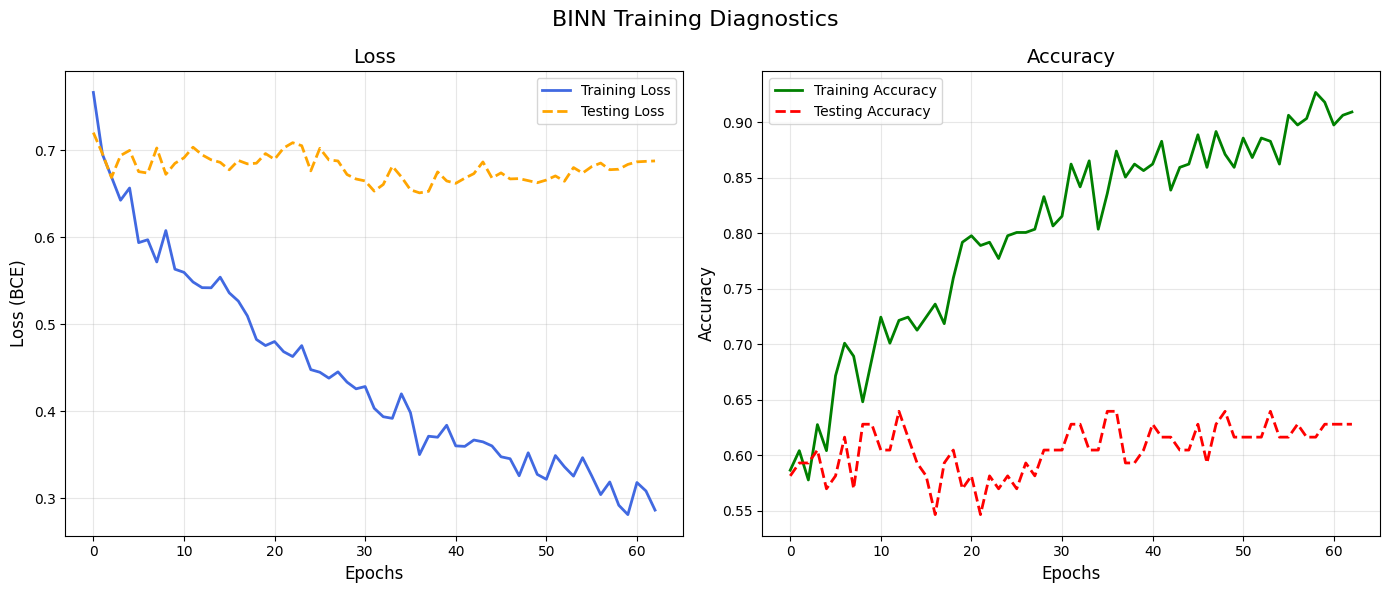

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
axes[0].plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (BCE)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
axes[1].plot(history['test_acc'], label='Testing Accuracy', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BINN Training Diagnostics', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
# CROSS VALIDATION
all_fold_scores = dh.run_cross_validation(adata_global, in_features, layers_list, tensor_masks, 
                                          device, k=5, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, 
                                          dropout=DROPOUT, activation_fn=ACTIVATION_FN)


--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.7812

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.7253

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6993

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6797

--- Starting Fold 5/5 ---
Fold 5 Best Test AUC: 0.7391

Mean ROC-AUC: 0.7249 +/- 0.0348


In [31]:
# Hyperparameter tuning, takes a while 
#best_params = dh.hyperparameter_tuning_optuna(adata_global, in_features, layers_list, tensor_masks, 
#                                              device, batch_size=BATCH_SIZE, activation_fn=ACTIVATION_FN,
#                                              k=5, epochs=EPOCHS)

Best train Loss: 0.2812 found at epoch 59 | Best train acc: 0.9267 found at epoch 58 || Best test Loss: 0.6512 found at epoch 36 | Best test acc: 0.6395 found at epoch 12
Saved: binn_test_results.csv


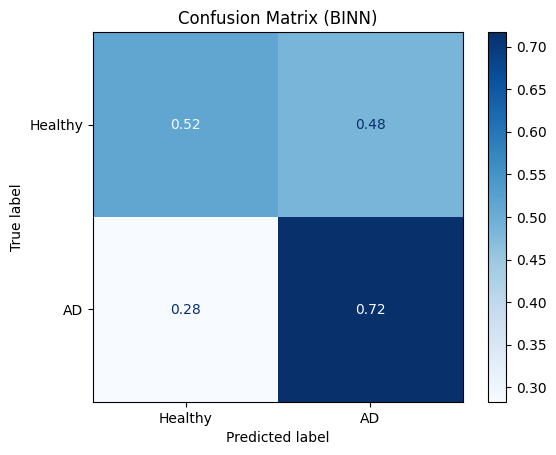

In [32]:
best_metrics = dh.fetch_best_metrics(history)
df_res = dh.save_test_results(binn, test_loader_global, device)
dh.confusion_matrix_binn(df_res)

In [33]:
report = dh.class_report(df_res)
report

Classification report for BINN:               precision    recall  f1-score   support

         0.0       0.53      0.52      0.52        33
         1.0       0.70      0.72      0.71        53

    accuracy                           0.64        86
   macro avg       0.62      0.62      0.62        86
weighted avg       0.64      0.64      0.64        86



'              precision    recall  f1-score   support\n\n         0.0       0.53      0.52      0.52        33\n         1.0       0.70      0.72      0.71        53\n\n    accuracy                           0.64        86\n   macro avg       0.62      0.62      0.62        86\nweighted avg       0.64      0.64      0.64        86\n'